In [3]:
!git clone https://github.com/mikolajkuna/GAMBA.git /home/ubuntu/GAMBA

fatal: destination path '/home/ubuntu/GAMBA' already exists and is not an empty directory.


In [4]:
!pip install -r /home/ubuntu/GAMBA/requirements.txt -q

In [5]:
!echo "=== Data ===" && ls /home/ubuntu/GAMBA/data/raw/
!echo "=== Config tail ===" && tail -3 /home/ubuntu/GAMBA/src/config.py
!pip show pymc pygam arviz | grep -E "Name|Version"

=== Data ===
salary_data_2009.csv
=== Config tail ===
MIN_GROUP_SIZE = 5
CV_EPS = 1e-6
RANDOM_SEED = 42
Name: pymc
Version: 5.25.1
License: Apache License, Version 2.0
Name: pygam
Version: 0.12.0
Name: arviz
Version: 0.23.4


In [6]:
!python3 -c "
with open('/home/ubuntu/GAMBA/src/config.py', 'r') as f:
    content = f.read()
# usuń błędną linię i dodaj poprawnie
content = content.replace('\\nRANDOM_SEED = 42', '')
content = content.rstrip() + '\nRANDOM_SEED = 42\n'
with open('/home/ubuntu/GAMBA/src/config.py', 'w') as f:
    f.write(content)
"
!tail -3 /home/ubuntu/GAMBA/src/config.py

SyntaxError: unterminated string literal (detected at line 9) (2130712632.py, line 9)

In [14]:
import sys
sys.path.insert(0, '/home/ubuntu/GAMBA')

from src.config import RAW_DATA, RANDOM_SEED, FIGURES_DIR
from src.dataset import load_raw_salary
from src.features import preprocess, make_xy

print(f"RAW_DATA: {RAW_DATA}")
print(f"RANDOM_SEED: {RANDOM_SEED}")
print(f"FIGURES_DIR: {FIGURES_DIR}")

ModuleNotFoundError: No module named 'sklearn'

In [8]:
import sys
print(sys.executable)

/home/ubuntu/.venv/bin/python3


In [12]:
!/home/ubuntu/.venv/bin/python3 -m ensurepip
!/home/ubuntu/.venv/bin/python3 -m pip install pandas -q
    

Looking in links: /tmp/tmpbqk8ioof
Processing /tmp/tmpbqk8ioof/pip-25.0.1-py3-none-any.whl

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [13]:
pip3 install --upgrade pip

SyntaxError: invalid syntax (3705398690.py, line 1)

In [16]:
!/home/ubuntu/.venv/bin/python3 -m pip install pandas numpy scikit-learn pygam pymc arviz matplotlib scipy joblib -q


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [1]:
import sys
sys.path.insert(0, '/home/ubuntu/GAMBA')

from src.config import RAW_DATA, RANDOM_SEED, FIGURES_DIR
from src.dataset import load_raw_salary
from src.features import preprocess, make_xy

print(f"RAW_DATA: {RAW_DATA}")
print(f"RANDOM_SEED: {RANDOM_SEED}")
print(f"FIGURES_DIR: {FIGURES_DIR}")

RAW_DATA: /home/ubuntu/GAMBA/data/raw/salary_data_2009.csv
RANDOM_SEED: 42
FIGURES_DIR: /home/ubuntu/GAMBA/reports/figures


In [2]:
# Wczytaj i sprawdź dane
df_raw = load_raw_salary(RAW_DATA)
print(f"Rows: {len(df_raw)}")
print(f"Columns: {list(df_raw.columns)}")
print(f"\nData types:\n{df_raw.dtypes}")
print(f"\nFirst 5 rows:\n{df_raw.head()}")
print(f"\nGender values: {df_raw['gender'].unique()}")
print(f"Job level values: {df_raw['job_level'].unique()}")
print(f"Education values: {df_raw['education_level'].unique()}")

Rows: 2000
Columns: ['age', 'gender', 'education_level', 'job_level', 'experience_years', 'distance_from_home', 'absence', 'child', 'income']

Data types:
age                   int64
gender                  str
education_level       int64
job_level             int64
experience_years      int64
distance_from_home    int64
absence               int64
child                 int64
income                int64
dtype: object

First 5 rows:
   age gender  education_level  job_level  experience_years  \
0   31      F                4          1                 0   
1   44      F                1          2                 0   
2   32      M                4          1                 0   
3   18      M                4          1                 0   
4   30      M                1          1                 0   

   distance_from_home  absence  child  income  
0                   1        0      0    4288  
1                   1        3      0    3537  
2                   1        1      0    

In [3]:
# Preprocessing
df = preprocess(df_raw)
X, y = make_xy(df)

print(f"After preprocessing: {len(df)} rows (was {len(df_raw)})")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nGender distribution: {df['gender'].value_counts().to_dict()}")
print(f"Job level distribution: {df['job_level'].value_counts().sort_index().to_dict()}")
print(f"Income stats:\n  min: {y.min():,.0f} PLN\n  max: {y.max():,.0f} PLN\n  mean: {y.mean():,.0f} PLN")

After preprocessing: 2000 rows (was 2000)
X shape: (2000, 8)
y shape: (2000,)

Gender distribution: {1: 1136, 0: 864}
Job level distribution: {1: 1559, 2: 209, 3: 76, 4: 156}
Income stats:
  min: 1,276 PLN
  max: 42,883 PLN
  mean: 7,906 PLN


/home/ubuntu/.venv/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(



--- LINEAR GAM (default GCV) ---
GCV: 54163905.83726629
AIC: 41347.90492772917

--- PERFORMANCE (LINEAR GAM (default GCV)) ---
MAE: 4,529 PLN
CV: 91.65%

--- GENDER PAY GAP (LINEAR GAM (default GCV)) ---
Adjusted Mean gap (counterfactual):   49 PLN
Adjusted Median gap (counterfactual): -254 PLN

--- GAP BY JOB LEVEL (LINEAR GAM (default GCV) - Adjusted/Counterfactual) ---
Job level Junior | mean gap: -229 PLN | n=1559
Job level Mid | mean gap: 1,575 PLN | n=209
Job level Senior | mean gap: 1,668 PLN | n=76
Job level Manager | mean gap: -6 PLN | n=156


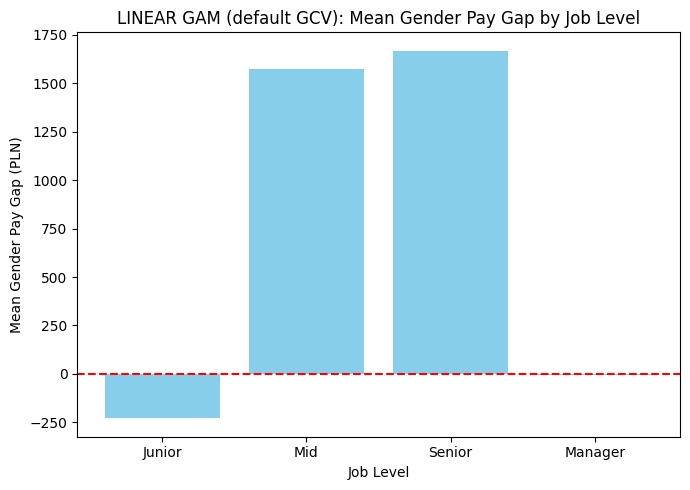

In [4]:
from src.modeling.train import train_linear_gam, train_gridsearch_gam, train_aic_gam

# GCV Default
gam_default, gap_default = train_linear_gam(str(RAW_DATA))

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--


Performing grid search with GCV objective...


100% (11 of 11) |########################| Elapsed Time: 0:00:10 Time:  0:00:100:00



--- GAM with GridSearch (GCV) ---
GCV: 53570964.78999877
AIC: 41335.220917321174

--- PERFORMANCE (GAM with GridSearch (GCV)) ---
MAE: 4,526 PLN
CV: 91.97%

--- GENDER PAY GAP (GAM with GridSearch (GCV)) ---
Adjusted Mean gap (counterfactual):   27 PLN
Adjusted Median gap (counterfactual): -199 PLN

--- GAP BY JOB LEVEL (GAM with GridSearch (GCV) - Adjusted/Counterfactual) ---
Job level Junior | mean gap: -132 PLN | n=1559
Job level Mid | mean gap: 437 PLN | n=209
Job level Senior | mean gap: 697 PLN | n=76
Job level Manager | mean gap: 746 PLN | n=156


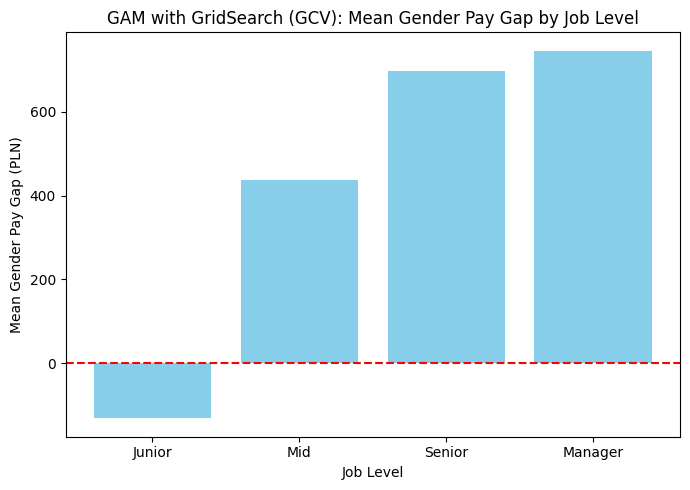

In [5]:
# Grid Search GCV
gam_gcv, gap_gcv = train_gridsearch_gam(str(RAW_DATA))

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--


Performing grid search with AIC objective...


100% (11 of 11) |########################| Elapsed Time: 0:00:09 Time:  0:00:090:00



--- GAM with GridSearch (AIC) ---
GCV: 53570964.78999877
AIC: 41335.220917321174

--- PERFORMANCE (GAM with GridSearch (AIC)) ---
MAE: 4,526 PLN
CV: 91.97%

--- GENDER PAY GAP (GAM with GridSearch (AIC)) ---
Adjusted Mean gap (counterfactual):   27 PLN
Adjusted Median gap (counterfactual): -199 PLN

--- GAP BY JOB LEVEL (GAM with GridSearch (AIC) - Adjusted/Counterfactual) ---
Job level Junior | mean gap: -132 PLN | n=1559
Job level Mid | mean gap: 437 PLN | n=209
Job level Senior | mean gap: 697 PLN | n=76
Job level Manager | mean gap: 746 PLN | n=156


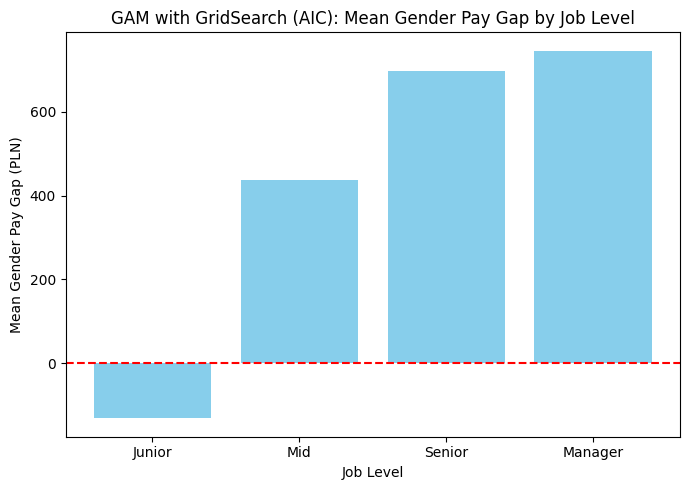

In [6]:
# Grid Search AIC
gam_aic, gap_aic = train_aic_gam(str(RAW_DATA))


Building Bayesian GAM with PyMC...

Sampling 2000 samples with 1000 tuning steps across 2 chains...
This may take several minutes...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_age, beta_exp, beta_abs, beta_child, beta_gender, beta_edu, beta_job, beta_dist, beta_gender_job, beta_gender_child, sigma]


/home/ubuntu/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/ubuntu/.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 18 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics



Sampling complete!

Computing posterior predictions...


Sampling: [y]


/home/ubuntu/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')


Computing counterfactual gender gap...
Computing posterior predictions for counterfactuals...

MCMC Diagnostics:
                       mean       sd    hdi_3%   hdi_97%  mcse_mean  mcse_sd  \
intercept          7791.721  644.348  6643.683  9020.844     15.922   11.245   
beta_gender         295.621  423.909  -468.126  1104.710      7.677    5.628   
beta_gender_child    81.480  251.403  -405.545   525.997      4.514    3.250   
sigma              7198.660  109.826  6985.429  7401.492      1.491    1.761   

                   ess_bulk  ess_tail  r_hat  
intercept            1644.0    2030.0    1.0  
beta_gender          3047.0    3065.0    1.0  
beta_gender_child    3089.0    3258.0    1.0  
sigma                5414.0    3383.0    1.0  

Gender Pay Gap - Bayesian Posterior:
Mean gap: 35 PLN
Median gap: 34 PLN
Std dev: 315 PLN
94% HDI: [-565, 603] PLN

Probability gap > 0: 54.4%
Probability gap > 50 PLN: 47.6%

Motherhood Penalty Analysis (gender × child):
beta_gender_child (interact

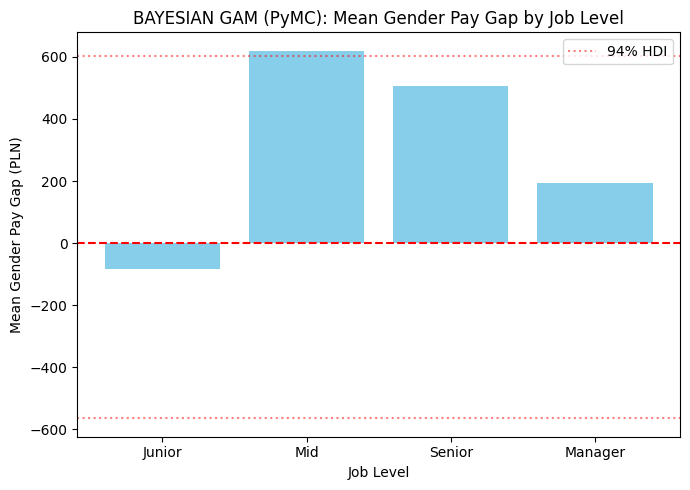

In [7]:
from src.modeling.train import train_bayesian_gam_pymc

bayes_model, gap_bayes = train_bayesian_gam_pymc(str(RAW_DATA))

In [8]:
# Podsumowanie wyników
print("=" * 60)
print("SUMMARY — Table 1 from paper")
print("=" * 60)
print(f"GCV Default      : {gap_default.mean():>6.0f} PLN")
print(f"Grid Search GCV  : {gap_gcv.mean():>6.0f} PLN")
print(f"Grid Search AIC  : {gap_aic.mean():>6.0f} PLN")
print(f"Bayesian PyMC    : {gap_bayes.mean():>6.0f} PLN")
print(f"                   94% HDI: [{bayes_model['gap_hdi'][0]:.0f}, {bayes_model['gap_hdi'][1]:.0f}] PLN")
print(f"                   P(gap > 0): {bayes_model['gap_prob_positive']:.1%}")

SUMMARY — Table 1 from paper
GCV Default      :     49 PLN
Grid Search GCV  :     27 PLN
Grid Search AIC  :     27 PLN
Bayesian PyMC    :     35 PLN
                   94% HDI: [-565, 603] PLN
                   P(gap > 0): 54.4%
